# Домашнее задание "Случайные величины и вероятности".

## Уровень 0:


### Задание 1

В магазин привезли устройства с 3-х разных предприятий.

Соотношение устройств следующее: 20% - продукция первого предприятия, 30% - продукция второго предприятия, 50% - продукция третьего предприятия; далее, 10% продукции первого предприятия высшего сорта, на втором предприятии - 5% и на третьем - 20% продукции высшего сорта.

Найти вероятность того, что случайно купленная новая продукция окажется высшего сорта.

In [ ]:
# простая запись решения
p1 = 0.2
p2 = 0.3
p3 = 0.5
x1 = 0.1
x2 = 0.05
x3 = 0.2

Ex = p1*x1 + p2*x2 + p3*x3

Ex

0.135

In [ ]:
# 1. Данные задачи (гипотезы и условные вероятности)
# Гипотезы: от какого предприятия устройство
prob_enterprise = [0.2, 0.3, 0.5]          # P(B_i)
prob_highest_given_enterprise = [0.1, 0.05, 0.2]  # P(A|B_i)

# 2. Формула полной вероятности:
# P(A) = Σ P(B_i) * P(A|B_i)
total_probability = 0.0
for i in range(len(prob_enterprise)):
    total_probability += prob_enterprise[i] * prob_highest_given_enterprise[i]

# 3. Результат
print(f"Вероятность того, что случайно купленное устройство окажется высшего сорта = {total_probability:.3f} ({total_probability*100:.1f}%)")

Вероятность того, что случайно купленное устройство окажется высшего сорта = 0.135 (13.5%)


In [ ]:
# Альтернативный, ещё более математичный вариант (для любителей функционального стиля)
import numpy as np

prob_enterprise = np.array([0.2, 0.3, 0.5])
prob_highest_given_enterprise = np.array([0.1, 0.05, 0.2])

# Скалярное произведение векторов = Σ P(B_i) * P(A|B_i)
total_probability = np.dot(prob_enterprise, prob_highest_given_enterprise)

print(f"P(A) = {total_probability:.3f}")

P(A) = 0.135


### Задание 2


Пусть брошены 3 уравновешенные монеты.

Рассмотрим 3 события:

A1 - монеты 1 и 2 упали одной и той же стороной;

A2 - монеты 2 и 3 упали одной и той же стороной;

A3 - монеты 1 и 3 упали одной и той же стороной.

Покажите, почему эти 3 события (A1, A2, A3) являются попарно независимыми, но не являются независимыми в совокупности.

In [ ]:
# простой вариант про попарную независимость
outcomes_per_coin = 2
coins = 3
outcomes_three_coins = outcomes_per_coin ** coins

p_a1_a2 = 2 / outcomes_three_coins
p_a1_a3 = p_a1_a2
p_a2_a3 = p_a1_a2

good_outcomes_two_coins = 2
outcomes_per_two_coins = 4

p_a1 = good_outcomes_two_coins / outcomes_per_two_coins
p_a2 = p_a1
p_a3 = p_a1

if (p_a1_a2 == p_a1 * p_a2) and (p_a1_a3 == p_a1 * p_a3) and (p_a2_a3 == p_a2 * p_a3):
    print('эти 3 события (A1, A2, A3) являются попарно независимыми')


эти 3 события (A1, A2, A3) являются попарно независимыми


In [ ]:
# причесанный вариант про попарную независимость и зависимость в совокупности

# ============================================================
# Задача: 3 уравновешенные монеты
# События:
#   A1 - монеты 1 и 2 упали одной стороной
#   A2 - монеты 2 и 3 упали одной стороной
#   A3 - монеты 1 и 3 упали одной стороной
# ============================================================

# --- Часть 1: Попарная независимость ---

# Всего исходов при броске 3 монет
total_outcomes = 2 ** 3  # 8

# Вероятность того, что две конкретные монеты упадут одинаково
# Из 4 возможных исходов для пары (ОО, ОР, РО, РР) благоприятны 2 (ОО и РР)
p_same_for_pair = 2 / 4  # 0.5

# Вероятность пересечения A1 и A2: все три монеты одинаковы
# Из 8 исходов благоприятны 2 (ООО и РРР)
p_both_A1_A2 = 2 / 8  # 0.25

# Из-за симметрии задачи остальные пары дают те же значения:
# P(A1 ∩ A3) = P(A2 ∩ A3) = P(A1 ∩ A2) = 0.25

# Проверка попарной независимости
if p_both_A1_A2 == p_same_for_pair * p_same_for_pair:
    print("Попарная независимость:")
    print("  P(A1 ∩ A2) = P(A1) · P(A2) = 0.25")
    print("  => События A1, A2, A3 являются попарно независимыми")
else:
    print("События не являются попарно независимыми")

print()  # пустая строка для разделения

# --- Часть 2: Независимость в совокупности ---

# Вероятность пересечения всех трёх событий: все три монеты одинаковы
# Из 8 исходов благоприятны 2 (ООО и РРР)
p_all_three = 2 / 8  # 0.25

# Произведение вероятностей отдельных событий
p_product = p_same_for_pair ** 3  # 0.5 * 0.5 * 0.5 = 0.125

# Проверка независимости в совокупности
if p_all_three == p_product:
    print("Независимость в совокупности:")
    print(f"  P(A1 ∩ A2 ∩ A3) = {p_all_three} = P(A1)·P(A2)·P(A3) = {p_product}")
    print("  => События являются независимыми в совокупности")
else:
    print("Независимость в совокупности:")
    print(f"  P(A1 ∩ A2 ∩ A3) = {p_all_three} ≠ P(A1)·P(A2)·P(A3) = {p_product}")
    print("  => События НЕ являются независимыми в совокупности, хотя попарно независимы")

# --- Часть 3 (дополнительно): Условная вероятность для объяснения ---

# P(A3 | A1 ∩ A2) = 1, потому что если 1=2 и 2=3, то автоматически 1=3
print()
print("Объяснение:")
print("  Если произошли A1 и A2 (1=2 и 2=3), то A3 (1=3) происходит обязательно.")
print("  P(A3 | A1 ∩ A2) = 1, а должно быть P(A3) = 0.5 для независимости в совокупности.")
print("  Поэтому независимости в совокупности нет.")

Попарная независимость:
  P(A1 ∩ A2) = P(A1) · P(A2) = 0.25
  => События A1, A2, A3 являются попарно независимыми

Независимость в совокупности:
  P(A1 ∩ A2 ∩ A3) = 0.25 ≠ P(A1)·P(A2)·P(A3) = 0.125
  => События НЕ являются независимыми в совокупности, хотя попарно независимы

Объяснение:
  Если произошли A1 и A2 (1=2 и 2=3), то A3 (1=3) происходит обязательно.
  P(A3 | A1 ∩ A2) = 1, а должно быть P(A3) = 0.5 для независимости в совокупности.
  Поэтому независимости в совокупности нет.


## Уровень 1:

### Задание 3


Изучите 3 распределения из библиотеки scipy: [Нормальное](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html), [Экспоненциальное](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html), [Стьюдента](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html). Используя функцию плотности распредления (`pdf`), постройте пять графиков плотностей для каждого распределения при разных параметрах. Запишите ваши наблюдения: как и на что влияют параметры у каждого распределения.

Дополнительная информация [тут](https://pythonguides.com/scipy-stats/).

In [ ]:
from scipy.stats import norm   # Нормальное распределение
from scipy.stats import expon  # Экспоненциальное распределение
from scipy.stats import t      # Распределение Стьюдента

In [ ]:
# создание списка объектов для каждого типа распределения с разными параметрами

# loc (среднее, μ) и scale (стандартное отклонение, σ)
norm_objects = [
    norm(loc=0, scale=1),    # Стандартный
    norm(loc=0, scale=0.5),  # Узкий
    norm(loc=0, scale=2),    # Широкий
    norm(loc=-2, scale=1),   # Сдвиг влево
    norm(loc=3, scale=1.5)   # Сдвиг вправо
]

# scale (среднее значение = 1/λ, где λ — интенсивность)
expon_objects = [
    expon(scale=0.5),  # Быстрое убывание
    expon(scale=1.0),  # Стандартное
    expon(scale=2.0),  # Среднее
    expon(scale=4.0),  # Медленное
    expon(scale=8.0)   # Очень медленное
]

# df (степени свободы), опционально loc и scale для сдвига и масштабирования
t_objects = [
    t(df=1, loc=0, scale=1),   # Коши (тяжёлые хвосты)
    t(df=3, loc=0, scale=1),   # Умеренно тяжёлые
    t(df=10, loc=0, scale=1),  # Почти нормальное
    t(df=30, loc=0, scale=1),  # Практически нормальное
    t(df=5, loc=1, scale=1.5)  # Сдвиг и масштаб
]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Подготовка данных для визуализации ---

# Создаём массив из 1000 точек от -6 до 6 для нормального распределения
# Это диапазон, в котором сосредоточена основная масса значений нормального распределения
x_norm = np.linspace(-6, 6, 1000)

# Создаём массив из 1000 точек от 0 до 20 для экспоненциального распределения
# Экспоненциальное распределение определено только для x >= 0
x_expon = np.linspace(0, 20, 1000)

# Создаём массив из 1000 точек от -10 до 10 для распределения Стьюдента
# У него могут быть тяжёлые хвосты, поэтому диапазон взят шире, чем у нормального
x_t = np.linspace(-10, 10, 1000)

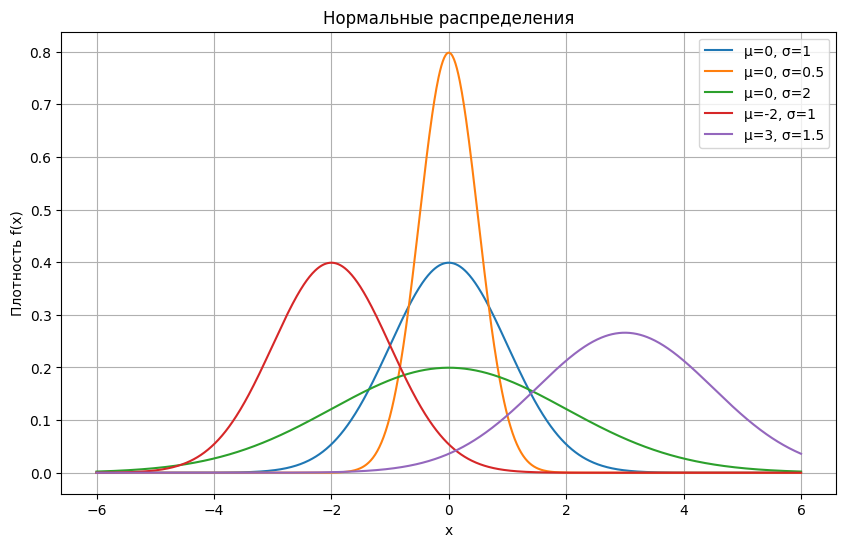

In [ ]:
# --- Визуализация нормальных распределений ---

# Создаём новый график с размером 10 дюймов по ширине и 6 дюймов по высоте
plt.figure(figsize=(10, 6))

# Перебираем все объекты нормального распределения из списка norm_objects
# enumerate возвращает индекс i и сам объект rv
for rv in norm_objects:
    # Для каждого распределения вычисляем значения плотности (pdf) в точках x_norm
    # rv.pdf(x_norm) возвращает массив значений плотности для всех точек
    # и сразу строим график зависимости плотности от x
    # label - подпись для легенды, которая показывает параметры распределения
    # rv.kwds["loc"] - извлекает параметр среднего (mu)
    # rv.kwds["scale"] - извлекает параметр стандартного отклонения (sigma)
    plt.plot(x_norm, rv.pdf(x_norm), label=f'μ={rv.kwds["loc"]}, σ={rv.kwds["scale"]}')

# Добавляем заголовок графика
plt.title('Нормальные распределения')

# Подписываем ось X (горизонтальная ось)
plt.xlabel('x')

# Подписываем ось Y (вертикальная ось) - это значения плотности вероятности
plt.ylabel('Плотность f(x)')

# Отображаем легенду, которая показывает соответствие цветов и параметров распределений
plt.legend()

# Включаем сетку на графике для удобства чтения значений
plt.grid()

# Отображаем построенный график на экране
plt.show()

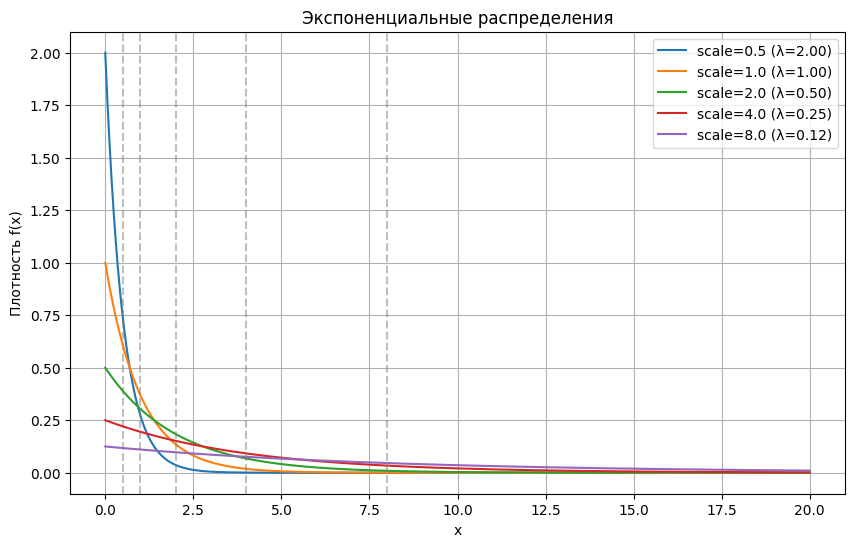

In [ ]:
# --- Визуализация экспоненциальных распределений ---

# Создаём новый график с размером 10 дюймов по ширине и 6 дюймов по высоте
plt.figure(figsize=(10, 6))

# Перебираем все объекты экспоненциального распределения из списка expon_objects
# enumerate возвращает индекс i и сам объект rv
for rv in expon_objects:
    # Для каждого распределения вычисляем значения плотности (pdf) в точках x_expon
    # rv.pdf(x_expon) возвращает массив значений плотности для всех точек
    # и сразу строим график зависимости плотности от x
    # label - подпись для легенды, которая показывает параметры распределения
    # rv.kwds.get("scale") - извлекает среднее значение (математическое ожидание) распределения 1/лямбда
    scale = rv.kwds.get('scale', 1)
    # параметр интенсивности распределения (сколько событий происходит в единицу времени)
    lambda_val = 1/scale
    plt.plot(x_expon, rv.pdf(x_expon), label=f"scale={scale} (λ={lambda_val:.2f})")
    # Показываем среднее значение вертикальной пунктирной линией
    plt.axvline(x=scale, color='gray', linestyle='--', alpha=0.5)

# Добавляем заголовок графика
plt.title('Экспоненциальные распределения')

# Подписываем ось X (горизонтальная ось)
plt.xlabel('x')

# Подписываем ось Y (вертикальная ось) - это значения плотности вероятности
plt.ylabel('Плотность f(x)')

# Отображаем легенду, которая показывает соответствие цветов и параметров распределений
plt.legend()

# Включаем сетку на графике для удобства чтения значений
plt.grid()

# Отображаем построенный график на экране
plt.show()

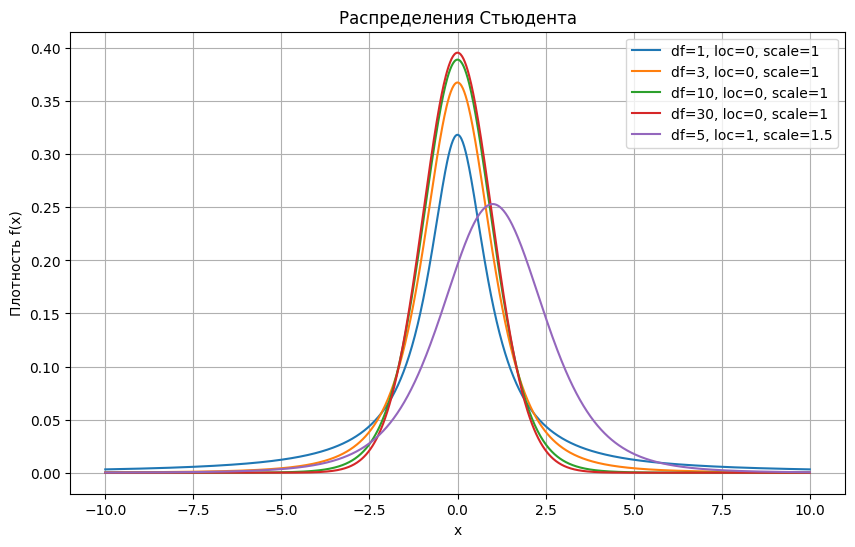

In [ ]:
# --- Визуализация распределений Стьюдента ---

# Создаём новый график с размером 10 дюймов по ширине и 6 дюймов по высоте
plt.figure(figsize=(10, 6))

# Перебираем все объекты распределения Стьюдента из списка t_objects
# enumerate возвращает индекс i и сам объект rv
for rv in t_objects:
    # Для каждого распределения вычисляем значения плотности (pdf) в точках x_t
    # rv.pdf(x_t) возвращает массив значений плотности для всех точек
    # и сразу строим график зависимости плотности от x
    # label - подпись для легенды, которая показывает параметры распределения
    # rv.kwds.get('df', 1) - извлекает параметр степени свободы
    # rv.kwds.get('loc', 0) - извлекает параметр сдвига
    # rv.kwds.get('scale', 1) - - извлекает параметр масштабирования
    plt.plot(x_t, rv.pdf(x_t), label=f"df={rv.kwds.get('df', 1)}, loc={rv.kwds.get('loc', 1)}, scale={rv.kwds.get('scale', 1)}")

# Добавляем заголовок графика
plt.title('Распределения Стьюдента')

# Подписываем ось X (горизонтальная ось)
plt.xlabel('x')

# Подписываем ось Y (вертикальная ось) - это значения плотности вероятности
plt.ylabel('Плотность f(x)')

# Отображаем легенду, которая показывает соответствие цветов и параметров распределений
plt.legend()

# Включаем сетку на графике для удобства чтения значений
plt.grid()

# Отображаем построенный график на экране
plt.show()

ВЫВОДЫ.
1. **Нормальное распределение**.
Чем больше сигма - стандартное отклонение от среднего, тем толще хвосты и более пологий пик, тем шире само распределение, изменение среднего от нуля сдвигает график

2. **Экспоненциальное распределение**.
Чем больше лямбда (интенсивность, которая показывает количество событий в единицу времени) и меньше среднее, тем "круче" распределение и быстрее затухание

3. **Распределение Стьюдента**.
При малом количестве степеней свободы у распределения тяжелые хвосты, при увеличении же этого параметра распределение стремится к нормальному. Сдвиг сдвигает график влево/вправо, масштабирование сужает/расширяет